# Compartment selection: DCIS → IDC and the genetic-vs-niche expression confound

A cancer clone founded in a duct **lumen** is not free to grow anywhere. Two normal compartments stand
in its way, and each imposes a **local death hazard** the clone can only overcome by evolving a matching
heritable trait (`DESIGN_phenotype_plasticity.md` §2):

$$\text{death} \mathrel{+}= \underbrace{\texttt{epithelial\_barrier}\cdot f_{\text{epi}}(\text{deme})\cdot(1-\texttt{breach})}_{\text{cross the gland wall}} \;+\; \underbrace{\texttt{stromal\_hazard}\cdot f_{\text{stro}}(\text{deme})\cdot(1-\texttt{stromal\_survival})}_{\text{survive the stroma}}$$

Both hazards key to the **live** cell fraction of the compartment (like the immune term), so they are
never a fixed label — they dilute as cancer accumulates. A lumen founder is therefore **confined**
(ductal carcinoma *in situ*, **DCIS**), spreading between glands only through lumen-to-lumen island
dispersal, until a subclone evolves `breach` (to cross the wall) and `stromal_survival` (to traverse the
stroma) — the **DCIS → IDC** transition (invasive ductal carcinoma).

There is a second, subtler consequence. The invasive **`emt`** expression program is driven by **two
sources at once**: the `breach` genotype (a **genetic** arm — `breach → emt` in the phenotype→program
map) *and* the local **epithelial niche** (`epithelial → emt`, a route-3 niche field). So a cell can
express the invasive program because of *what it is* (genotype) or *where it sits* (niche). In a real
scRNA + spatial dataset these are **confounded** — "invasive expression ⇒ invasive genotype" is not
safe. iscc generates **both** contributions, so it can measure the confound directly.

This notebook analyses the tumour as a real study would — the **mixture** of malignant +
microenvironment, never pre-filtered to cancer. The full validation is
`validation/validate_compartment_selection.py`.

In [1]:
%matplotlib inline
import os, sys, time
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import base_sim as B
from iscc.tumor.models import GenotypeTumor
from iscc.tumor import viz
from iscc.data import scRNA

## 1. Watch the DCIS → IDC transition

We grow the shared tumour (barriers ON) and snapshot it at five milestones.

* **Top row — the tissue** (cell resolution): green gland walls, pink stroma, **red** cancer. Cancer
  fills the lumens (DCIS), then breaks through into the stroma (IDC).
* **Bottom row — cancer by compartment**: cancer **confined in a gland** (DCIS) is **steel-blue**;
  cancer that has invaded the **stroma** (IDC) is **crimson**. The blue foci appear first and the
  crimson invasive mass grows late — the *in situ* → invasive transition.

grown to 12,833 cancer cells | 12/12 glands | 41% in stroma (IDC), 59% confined (DCIS)


Text(0.5, 0.98, 'Compartment selection: confined multi-focal DCIS breaking out into the stroma (IDC)')

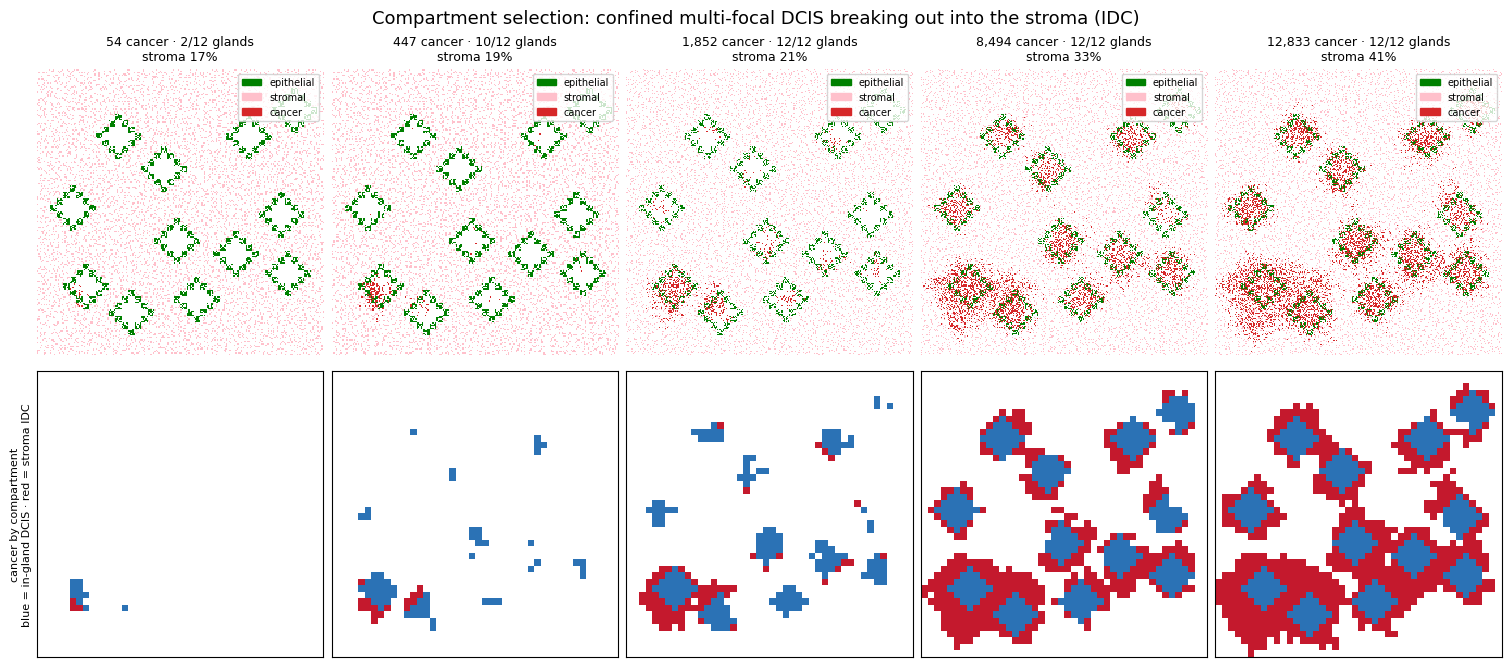

In [2]:
MILESTONES = [40, 400, 1500, 5000, 10000]
t = GenotypeTumor(seed=B.BASE_SEED, genome_params=B.GENOME, selection_params=B.SELECTION,
                  cancer_cell_params=B.CANCER, deme_params=B.DEME, spatial_params=B.SPATIAL,
                  expression_params=B.EXPR(), update_mode="tau", tau=1.0)
snaps, mi, on_traj = [], 0, []
while True:
    ncan = B._n_cancer(t)
    on_traj.append((t.step, ncan, B.stroma_cancer_pct(t)))
    if mi < len(MILESTONES) and ncan >= MILESTONES[mi]:
        t.make_cell_data()
        snaps.append(dict(ncan=ncan, ngl=len(B.glands_colonised(t)), stroma=B.stroma_cancer_pct(t),
                          cd=t.cell_data, gland_grid=B.cancer_gland_grid(t)))
        mi += 1
    if ncan >= MILESTONES[-1]:
        break
    t.grow(n_steps=(1 if ncan < 2500 else 2), seed=B.BASE_SEED)
t.make_cell_data()
print(f"grown to {B._n_cancer(t):,} cancer cells | {len(B.glands_colonised(t))}/{t.n_glands} glands | "
      f"{B.stroma_cancer_pct(t):.0f}% in stroma (IDC), {100-B.stroma_cancer_pct(t):.0f}% confined (DCIS)")
assert B._n_cancer(t) >= 10000

ncol = len(snaps)
fig, axes = plt.subplots(2, ncol, figsize=(3.0 * ncol, 6.6), constrained_layout=True)
for k, s in enumerate(snaps):
    viz.plot_grid(s["cd"], t.grid_size, t.traces, t.genotypes_parents, color=["cell_type"],
                  ax=axes[0, k], expand_demes=True, section_frac=0.4, cancer_color="#d62728")
    axes[0, k].set_title(f"{s['ncan']:,} cancer · {s['ngl']}/{t.n_glands} glands\nstroma {s['stroma']:.0f}%",
                         fontsize=9)
    grid = s["gland_grid"]; rgb = np.ones((*grid.shape, 3))
    rgb[grid >= 0] = (0.17, 0.45, 0.71)   # confined DCIS  -> steel blue
    rgb[grid == -1] = (0.77, 0.10, 0.18)  # stroma-invaded IDC -> crimson
    axes[1, k].imshow(rgb, interpolation="nearest"); axes[1, k].set_xticks([]); axes[1, k].set_yticks([])
axes[0, 0].set_ylabel("tissue (cells)\ngreen wall · red cancer · pink stroma", fontsize=8)
axes[1, 0].set_ylabel("cancer by compartment\nblue = in-gland DCIS · red = stroma IDC", fontsize=8)
fig.suptitle("Compartment selection: confined multi-focal DCIS breaking out into the stroma (IDC)", fontsize=13)

## 2. The escape traits sit at the invasion front

`breach` and `stromal_survival` are **sequenceable** heritable traits (mutations at designated genes),
so they land in `cell_data` and in DNA-seq. Coloured over the final section: the malignant cells that
reached the **stroma** carry elevated `stromal_survival` — that trait is selected exactly where its
barrier acts. `breach` sweeps to **near-fixation** across the whole lesion early on (it is beneficial
wherever the wall is, and accumulates fast), so within this tumour it is nearly uniform; its selection
shows up most cleanly against the barrier-OFF control in §3. (Gland walls drawn for context.)

mean breach — in gland 0.93 vs in stroma 0.92
mean stromal_survival — in gland 0.87 vs in stroma 0.91


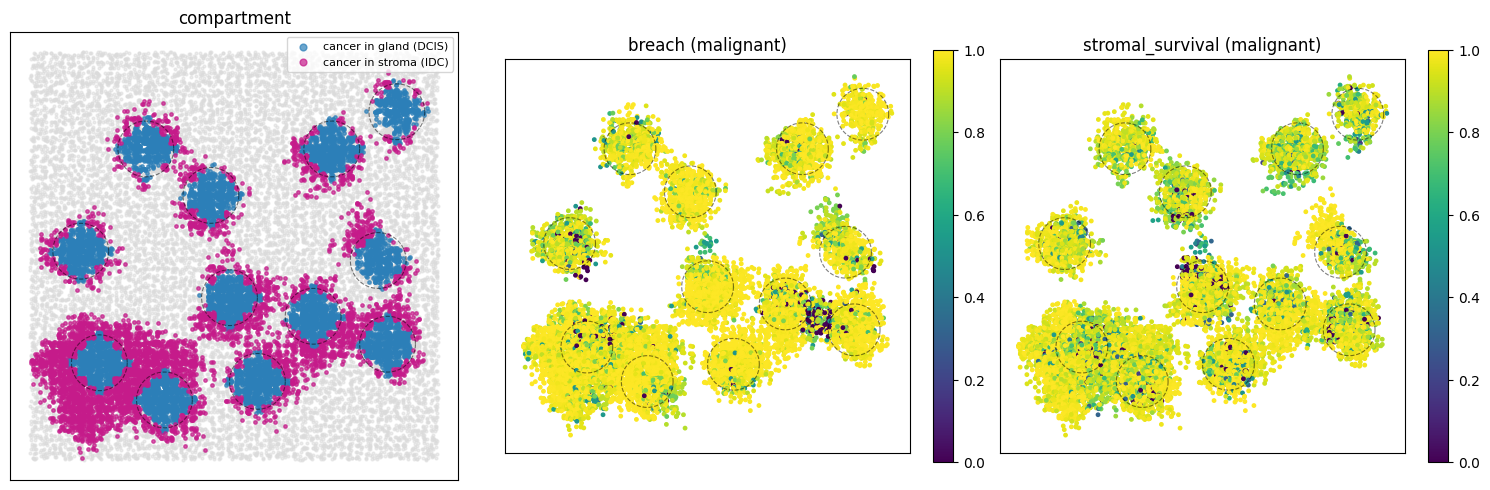

In [3]:
cd = t.cell_data
ty = B.cell_types(t); cancer = ty == "cancer"
gland = B.cell_gland(t)
jit = np.random.default_rng(1)
jx = cd["cell_crd"]["col"].values + jit.uniform(-0.42, 0.42, len(ty))
jy = cd["cell_crd"]["row"].values + jit.uniform(-0.42, 0.42, len(ty))
breach = B.cell_trait(t, "breach"); ss = B.cell_trait(t, "stromal_survival")

fig, axes = plt.subplots(1, 3, figsize=(15, 5.0))
# (a) compartment: microenvironment grey, in-gland cancer blue, stroma-invaded cancer red
axes[0].scatter(jx[~cancer], jy[~cancer], s=4, c="0.86", alpha=0.5)
axes[0].scatter(jx[cancer & (gland >= 0)], jy[cancer & (gland >= 0)], s=6, c="#2c7fb8", alpha=0.7,
                label="cancer in gland (DCIS)")
axes[0].scatter(jx[cancer & (gland == -1)], jy[cancer & (gland == -1)], s=6, c="#c51b8a", alpha=0.7,
                label="cancer in stroma (IDC)")
B.draw_glands(axes[0], t); axes[0].legend(fontsize=8, markerscale=2, loc="upper right")
axes[0].set_title("compartment"); axes[0].set_aspect("equal"); axes[0].invert_yaxis()
axes[0].set_xticks([]); axes[0].set_yticks([])
for ax, val, name in [(axes[1], breach, "breach"), (axes[2], ss, "stromal_survival")]:
    m = cancer & np.isfinite(val)
    sc = ax.scatter(jx[m], jy[m], s=6, c=val[m], cmap="viridis", vmin=0, vmax=1)
    B.draw_glands(ax, t); ax.set_title(f"{name} (malignant)"); ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([]); plt.colorbar(sc, ax=ax, fraction=0.046)
plt.tight_layout()
print(f"mean breach — in gland {breach[cancer & (gland>=0)].mean():.2f} vs in stroma {breach[cancer & (gland==-1)].mean():.2f}")
print(f"mean stromal_survival — in gland {ss[cancer & (gland>=0)].mean():.2f} vs in stroma {ss[cancer & (gland==-1)].mean():.2f}")

## 3. The barrier delays stromal invasion (a matched barrier-OFF control)

We grow a **matched control** with the compartment barriers switched off
(`epithelial_barrier = stromal_hazard = 0`) — same seed, same everything else. With no wall and no
hostile stroma to gate it, the control **invades the stroma immediately**, while the barriers-ON lesion
stays confined for many generations (the DCIS phase). And the escape traits are only selected where
their barrier acts: mean `breach` is far higher with the barriers ON, and `stromal_survival` is highest
in cells that reached the stroma.

at match, stroma-invading cancer — ON 41% vs OFF 46%
mean breach — ON 0.93 vs OFF 0.77


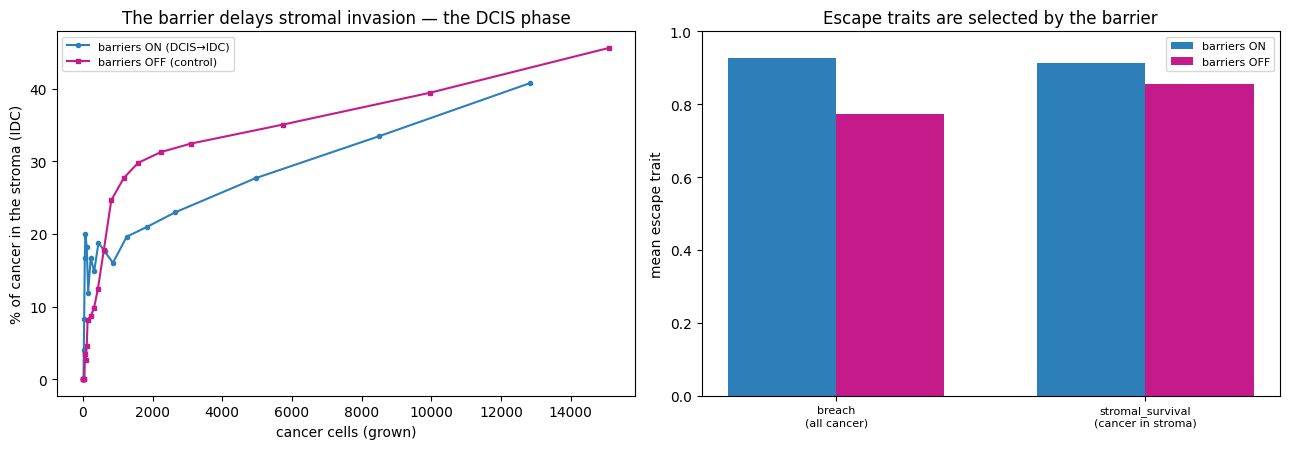

In [4]:
t_off = GenotypeTumor(seed=B.BASE_SEED, genome_params=B.GENOME, selection_params=B.SELECTION,
                      cancer_cell_params=B.CANCER, deme_params=B.DEME,
                      spatial_params=dict(B.SPATIAL, epithelial_barrier=0.0, stromal_hazard=0.0),
                      expression_params=B.EXPR(), update_mode="tau", tau=1.0)
off_traj = []
while B._n_cancer(t_off) < MILESTONES[-1]:
    off_traj.append((t_off.step, B._n_cancer(t_off), B.stroma_cancer_pct(t_off)))
    ncan = B._n_cancer(t_off)
    t_off.grow(n_steps=(1 if ncan < 2500 else 2), seed=B.BASE_SEED)
off_traj.append((t_off.step, B._n_cancer(t_off), B.stroma_cancer_pct(t_off)))
t_off.make_cell_data()
gland_off = B.cell_gland(t_off); can_off = B.cell_types(t_off) == "cancer"
breach_off = B.cell_trait(t_off, "breach"); ss_off = B.cell_trait(t_off, "stromal_survival")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
on = np.array(on_traj); off = np.array(off_traj)
axes[0].plot(on[:, 1], on[:, 2], "-o", ms=3, color="#2c7fb8", label="barriers ON (DCIS→IDC)")
axes[0].plot(off[:, 1], off[:, 2], "-s", ms=3, color="#c51b8a", label="barriers OFF (control)")
axes[0].set_xlabel("cancer cells (grown)"); axes[0].set_ylabel("% of cancer in the stroma (IDC)")
axes[0].set_title("The barrier delays stromal invasion — the DCIS phase"); axes[0].legend(fontsize=8)

labels = ["breach\n(all cancer)", "stromal_survival\n(cancer in stroma)"]
on_vals = [np.nanmean(breach[cancer]),
           np.nanmean(ss[cancer & (gland == -1)]) if (cancer & (gland == -1)).any() else np.nan]
off_vals = [np.nanmean(breach_off[can_off]),
            np.nanmean(ss_off[can_off & (gland_off == -1)]) if (can_off & (gland_off == -1)).any() else np.nan]
xp = np.arange(2); w = 0.35
axes[1].bar(xp - w/2, on_vals, w, color="#2c7fb8", label="barriers ON")
axes[1].bar(xp + w/2, off_vals, w, color="#c51b8a", label="barriers OFF")
axes[1].set_xticks(xp); axes[1].set_xticklabels(labels, fontsize=8); axes[1].set_ylim(0, 1)
axes[1].set_ylabel("mean escape trait"); axes[1].set_title("Escape traits are selected by the barrier")
axes[1].legend(fontsize=8)
plt.tight_layout()
print(f"at match, stroma-invading cancer — ON {B.stroma_cancer_pct(t):.0f}% vs OFF {B.stroma_cancer_pct(t_off):.0f}%")
print(f"mean breach — ON {on_vals[0]:.2f} vs OFF {off_vals[0]:.2f}")
del t_off

## 4. The confound: is invasive *expression* driven by genotype or by niche?

Now the payoff iscc uniquely enables. We run **scRNA on the mixture** and read the **invasive (`emt`)
program** activity of the malignant cells. Because iscc drives `emt` from **both** the `breach` genotype
**and** the epithelial niche, we can ask the question a real study cannot answer:

1. **Partial correlation** — controlling for genotype (subtracting each clone's own mean `emt`), does
   `emt` *still* rise with the **epithelial fraction** of a cell's niche? A positive residual
   correlation means location drives invasive expression **independently of genotype** — so "invasive
   expression ⇒ invasive genotype" is confounded.
2. **Variance split** — iscc knows the genetic drive (`clone_drive`, from the genotype) and the niche
   drive (`niche_drive`, from the epithelial field) separately, so we can report what share of the
   `emt`-drive variance each arm contributes.

scRNA on the mixture: 850 cells (500 malignant + 350 microenvironment)


corr(emt, epithelial fraction): raw 0.77 -> genotype-controlled 0.43
emt-drive variance: genetic 0.030 | niche 0.624  (niche share 95%)


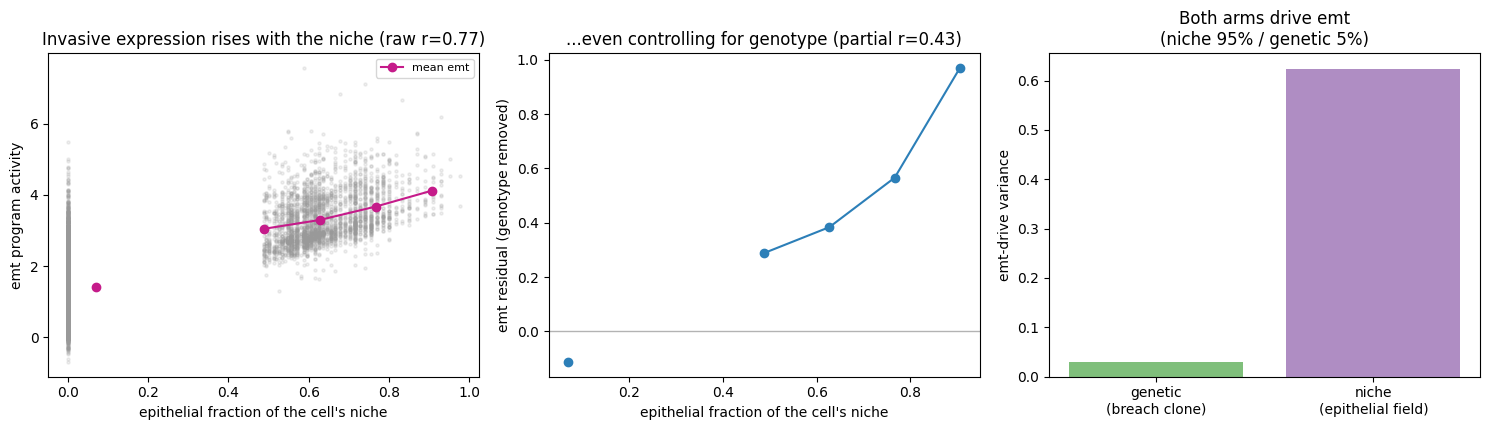

In [5]:
# scRNA on a realistic-purity mixture (establish we're reading observed expression of the mixture)
rng = np.random.default_rng(0)
idx = np.asarray(cd["cell_type"].index)
cancer_cells = list(rng.choice(idx[cancer], size=500, replace=False))
normal_cells = list(rng.choice(idx[np.isin(ty, ("epithelial", "stromal"))], size=350, replace=False))
mixture = cancer_cells + normal_cells
_ = scRNA(n_cells=len(mixture), protocol="10x", seed=1).run(cd, cell_subset=mixture)
print(f"scRNA on the mixture: {len(mixture)} cells ({len(cancer_cells)} malignant + {len(normal_cells)} microenvironment)")

# the invasive-program activity (ground truth iscc knows) + the niche it sits in, malignant cells only
emt_k = list(t.programs.dictionary.program_names).index("emt")
emt = cd["cell_program"].values[:, emt_k]
epi_frac = B.cell_epithelial_fraction(t)
gid = cd["cell_type"]["cell_id"].values
emt_c, epi_c, gid_c = emt[cancer], epi_frac[cancer], gid[cancer]

# (1) genotype-controlled (partial) correlation: subtract each clone's own mean emt
resid = emt_c.astype(float).copy()
for g in np.unique(gid_c):
    m = gid_c == g
    resid[m] = emt_c[m] - emt_c[m].mean()
r_raw = np.corrcoef(emt_c, epi_c)[0, 1]
r_partial = np.corrcoef(resid, epi_c)[0, 1]

# (2) variance split: iscc's genetic (clone_drive) vs niche (niche_drive) emt drive
niche_emt = t.programs.niche_drive(
    {"epithelial": t.microenv_truth["epithelial"], "stromal": t.microenv_truth["stromal"]}
)[:, emt_k][cd["cell_deme"]["deme_id"].values]
gen_emt = np.array([t.programs.clone_drive(r.evolutionary_parameters, r.baseline_rates, r.get_snvs())[emt_k]
                    if r.type == "cancer" else 0.0 for r in (t.genotypes[g] for g in gid)])
var_gen, var_niche = float(np.var(gen_emt[cancer])), float(np.var(niche_emt[cancer]))
frac_niche = var_niche / (var_gen + var_niche)
print(f"corr(emt, epithelial fraction): raw {r_raw:.2f} -> genotype-controlled {r_partial:.2f}")
print(f"emt-drive variance: genetic {var_gen:.3f} | niche {var_niche:.3f}  (niche share {frac_niche*100:.0f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
# binned emt vs epithelial fraction (raw and genotype-controlled residual)
bins = np.linspace(0, epi_c.max() + 1e-9, 8)
bc = 0.5 * (bins[1:] + bins[:-1]); which = np.clip(np.digitize(epi_c, bins) - 1, 0, len(bc) - 1)
raw_m = [emt_c[which == i].mean() if (which == i).any() else np.nan for i in range(len(bc))]
res_m = [resid[which == i].mean() if (which == i).any() else np.nan for i in range(len(bc))]
axes[0].scatter(epi_c, emt_c, s=5, alpha=0.15, color="0.6")
axes[0].plot(bc, raw_m, "-o", color="#c51b8a", label="mean emt")
axes[0].set_xlabel("epithelial fraction of the cell's niche"); axes[0].set_ylabel("emt program activity")
axes[0].set_title(f"Invasive expression rises with the niche (raw r={r_raw:.2f})"); axes[0].legend(fontsize=8)
axes[1].axhline(0, color="0.7", lw=1)
axes[1].plot(bc, res_m, "-o", color="#2c7fb8")
axes[1].set_xlabel("epithelial fraction of the cell's niche")
axes[1].set_ylabel("emt residual (genotype removed)")
axes[1].set_title(f"...even controlling for genotype (partial r={r_partial:.2f})")
axes[2].bar(["genetic\n(breach clone)", "niche\n(epithelial field)"], [var_gen, var_niche],
            color=["#7fbf7b", "#af8dc3"])
axes[2].set_ylabel("emt-drive variance")
axes[2].set_title(f"Both arms drive emt\n(niche {frac_niche*100:.0f}% / genetic {100-frac_niche*100:.0f}%)")
plt.tight_layout()

## What this shows

* **DCIS → IDC is emergent selection.** A lumen founder is confined by the epithelial wall and the
  hostile stroma (multi-focal **DCIS**), and invades (**IDC**) only once escape traits evolve — traits a
  barrier-OFF control never needs. `stromal_survival` is selected where the stroma is; `breach` is
  selected far above the barrier-OFF control (`breach` ON ≫ OFF).
* **The genetic-vs-niche expression confound is real and quantified.** The invasive `emt` program rises
  with a cell's **epithelial niche even after controlling for its genotype** (positive partial
  correlation ≈ 0.4), so invasive *expression* does not imply an invasive *genotype*. iscc drives `emt`
  from **both** arms and can split the drive variance — the attribution question no real scRNA + spatial
  dataset can settle, posed here with ground truth.
* **Honest note on the variance split.** On this large multi-focal field the **niche** arm dominates the
  `emt`-drive variance: the epithelial fraction ranges from ~0 (deep stroma) to ~1 (gland walls), a huge
  spread, whereas `breach` sweeps to near-fixation (little genetic variance left). The genetic arm is
  real but small here; `validation/validate_compartment_selection.py` reports a more balanced split on a
  smaller field. The *partial correlation* (location drives `emt` independently of genotype) is the
  robust, field-size-independent statement.

**Next / see also:**
[`base_simulation`](base_simulation.ipynb) (the shared substrate) ·
[`gene_programs`](gene_programs.ipynb) (the program layer + a mini version of this confound) ·
[`tree_inference_dna`](tree_inference_dna.ipynb) (the multi-focal spread tree) ·
`validation/validate_compartment_selection.py` · `validation/validate_ductal_field.py`.